In [2]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [3]:
using Revise
includet("./base.jl")

In [4]:
using ColorSchemes

In [5]:
using ColorSchemes

In [6]:
using GLMakie
using CairoMakie
CairoMakie.activate!()
using Statistics

Load data
This reduced data has everything except the full state at every time point (so no space-time diagrams here)# Load data
This reduced data has everything except the full state at every time point (so no space-time diagrams here)

In [7]:
f = jldopen("test1.jld2")

JLDFile /home/honza/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/cluster_env/runs/si_pdes1/main4_totbiom/test1.jld2 (read-only)
 ├─🔢 metadata
 └─🔢 df

# final_T distribution

In [9]:
f = jldopen("test1.jld2")

JLDFile /home/honza/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/cluster_env/runs/si_pdes1/main4_totbiom/test1.jld2 (read-only)
 ├─🔢 metadata
 └─🔢 df

In [10]:
setup_df = load("systems.jld2", "pde_df")   # params, Ds, u0 - join on pde_df_row
odes_df = load("test1.jld2", "df")   # the ode solutions
df = load("run_stats.jld2", "df")
smd = load("systems.jld2", "metadata")
T = setup_df.T[1]

Ns = Nr = 20

df1 = df[df.run .== "data",Not(:run)]
df2 = df[df.run .== "st4",Not(:run)]
@show nrow(df1), nrow(df2)

heavy = [:final_state, :saved_ts, :biomass_t]
first(select(df, Not(heavy)), 6)

(nrow(df1), nrow(df2)) = (60, 60)

Row,run,pde_df_row,gdf_row,df_row,p,L,sN,T,retcode,final_T,maxresid,num_saved,realtime
,String,Int64,Int64,Int64,Float64,Float64,Int64,Float64,T,Float64,Float64,Int64,Float64
1,data,1,1,10,1.0,40.5011,1000,1.0e8,Success,1.0e8,9.39688e-8,348,7411.12
2,data,2,1,10,0.1,40.5011,1000,1.0e8,Success,1.0e8,1.36819e-8,598,8677.53
3,data,3,2,97,1.0,42.1673,1000,1.0e8,Success,1.0e8,3.19538e-9,328,7627.2
4,data,4,2,97,0.1,42.1673,1000,1.0e8,Success,1.0e8,4.89386e-13,63,516.978
5,data,5,3,79,1.0,44.2575,1000,1.0e8,Success,1.0e8,2.46566e-8,337,7721.0
6,data,6,3,79,0.1,44.2575,1000,1.0e8,Success,1.0e8,4.12115e-13,62,514.437


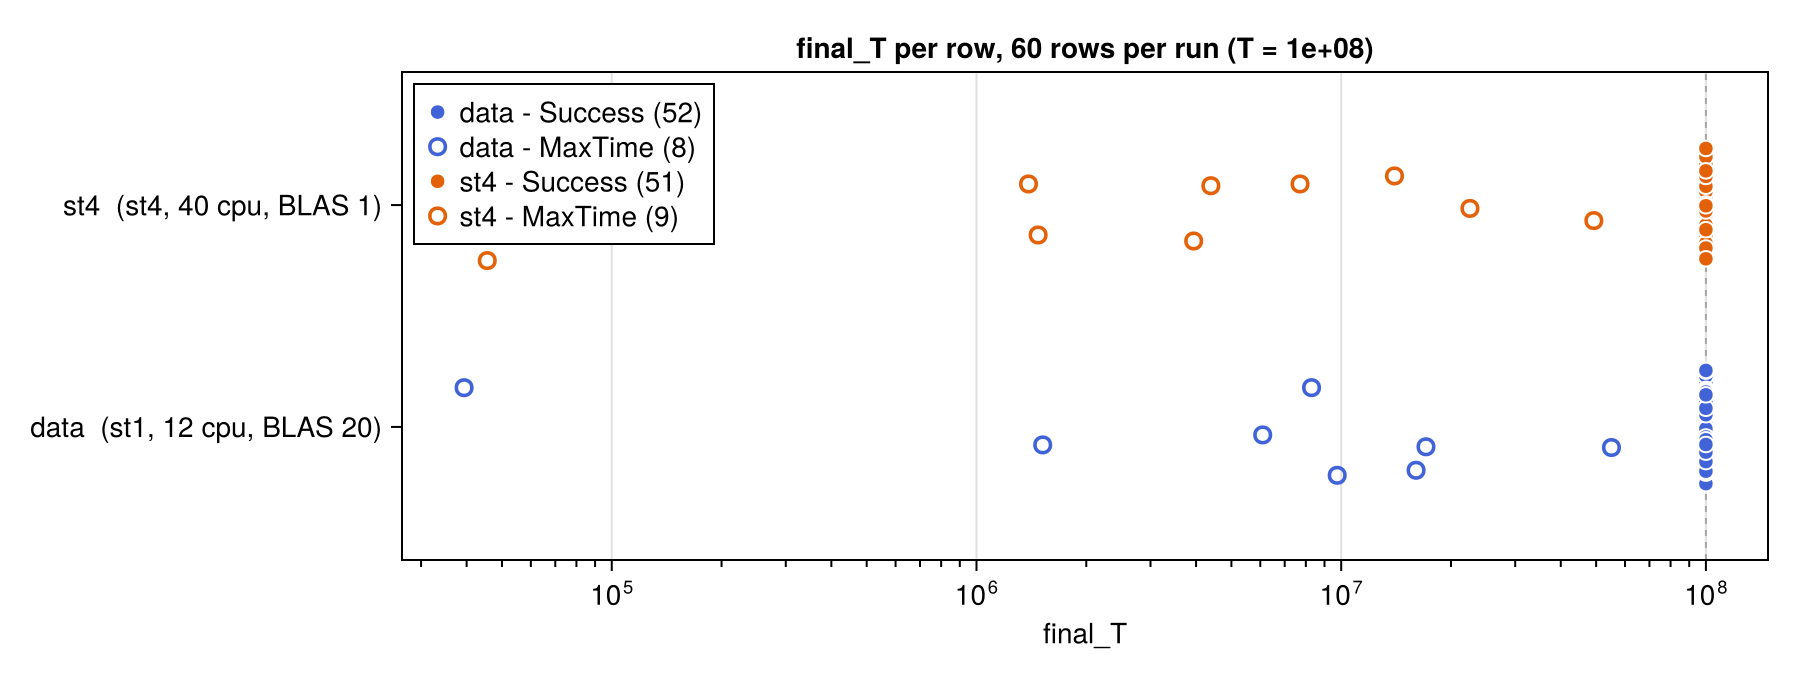

In [11]:
using Random

order = ["data", "st4"]
labels = Dict("data" => "data  (st1, 12 cpu, BLAS 20)", "st4" => "st4  (st4, 40 cpu, BLAS 1)")
colors = Dict("data" => "#4063D8", "st4" => "#E36209")  # CVD separation dE 29 at worst

fig = Figure(; size=(900, 340))
ax = Axis(fig[1, 1];
    xscale=log10, xlabel="final_T", ylabel="",
    title=@sprintf("final_T per row, %d rows per run (T = %.3g)", length(unique(df.pde_df_row)), T),
    yticks=(1:length(order), [labels[k] for k in order]),
    xminorticksvisible=true, xminorticks=IntervalsBetween(9),
    ygridvisible=false,
)

vlines!(ax, T; color=:grey65, linestyle=:dash, linewidth=1)  # where every Success row sits

Random.seed!(1)  # so the jitter redraws the same each time
for (j, k) in enumerate(order)
    g = df[df.run.==k, :]
    ok = g.retcode .== ReturnCode.Success
    ys = j .+ 0.26 .* (2 .* rand(nrow(g)) .- 1)  # jitter, the y axis carries no data
    # retcode goes on fill rather than colour, so it survives greyscale
    scatter!(ax, g.final_T[ok], ys[ok];
        color=colors[k], markersize=11, strokewidth=1, strokecolor=:white,
        label=@sprintf("%s - Success (%d)", k, count(ok)))
    scatter!(ax, g.final_T[.!ok], ys[.!ok];
        color=(:white, 0.0), markersize=11, strokewidth=1.8, strokecolor=colors[k],
        label=@sprintf("%s - MaxTime (%d)", k, count(.!ok)))
end

ylims!(ax, 0.4, length(order) + 0.6)
axislegend(ax; position=:lt, framevisible=true, patchsize=(12, 12), rowgap=1)

CairoMakie.save("final_T_distribution.pdf", fig)  # save is ambiguous unqualified
fig

Total  as a function of t# Total biomass as a function of t

# Total biomass in time

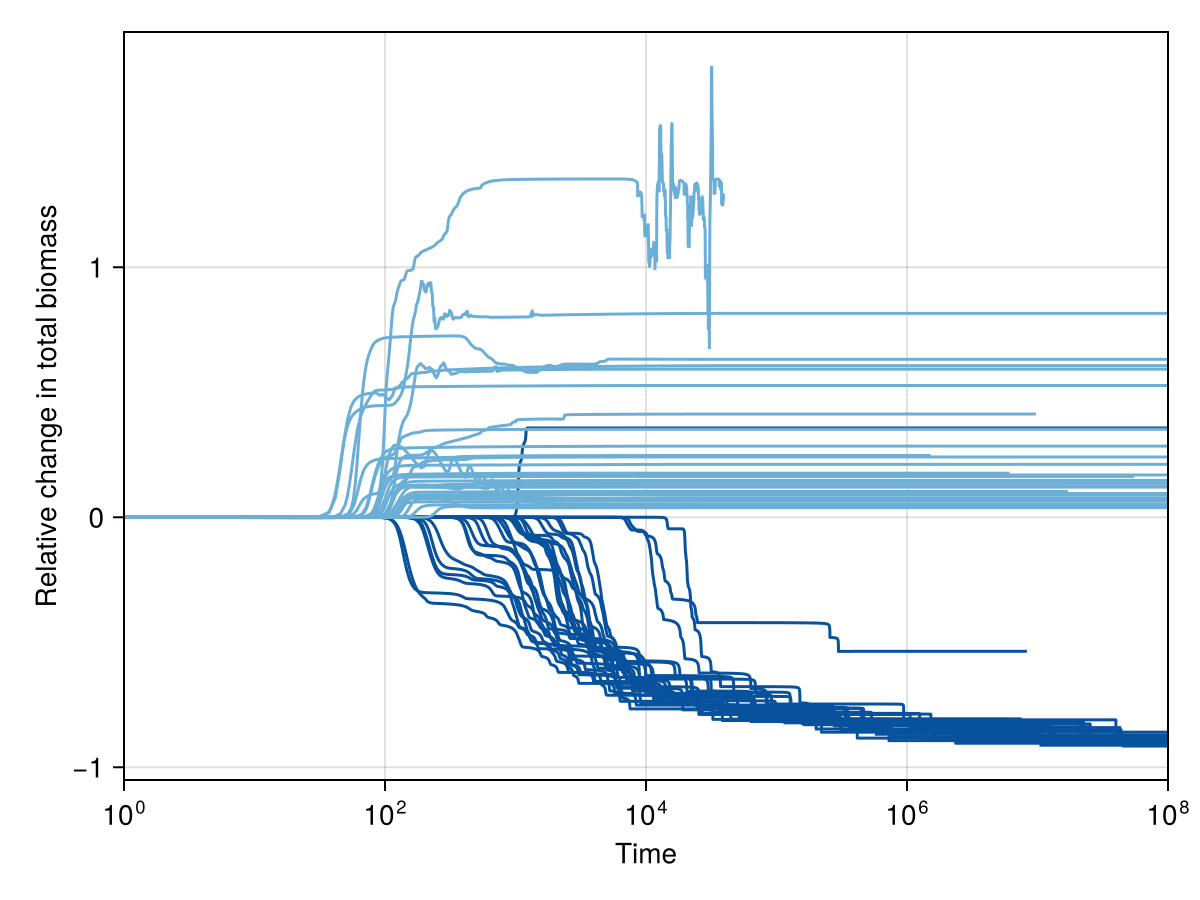

In [23]:
fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
    xlabel="Time",
    ylabel="Relative change in total biomass",
)

for (p, pcol) in zip(smd.ps, pcols)
    for i in findall(==(p), df1.p)
        r = df1[i,:]
        ts = r.saved_ts
        totb = r.biomass_t
        
        ode_r = odes_df[r.df_row,:]
        hss_totbiom = sum(ode_r.final_states[1:Ns])
        
        lines!(ax, ts, (totb .- hss_totbiom) ./ hss_totbiom;
            color=pcol
        )
    end
end

xlims!(ax, 1., 1e8)

fig

# Looking at one row

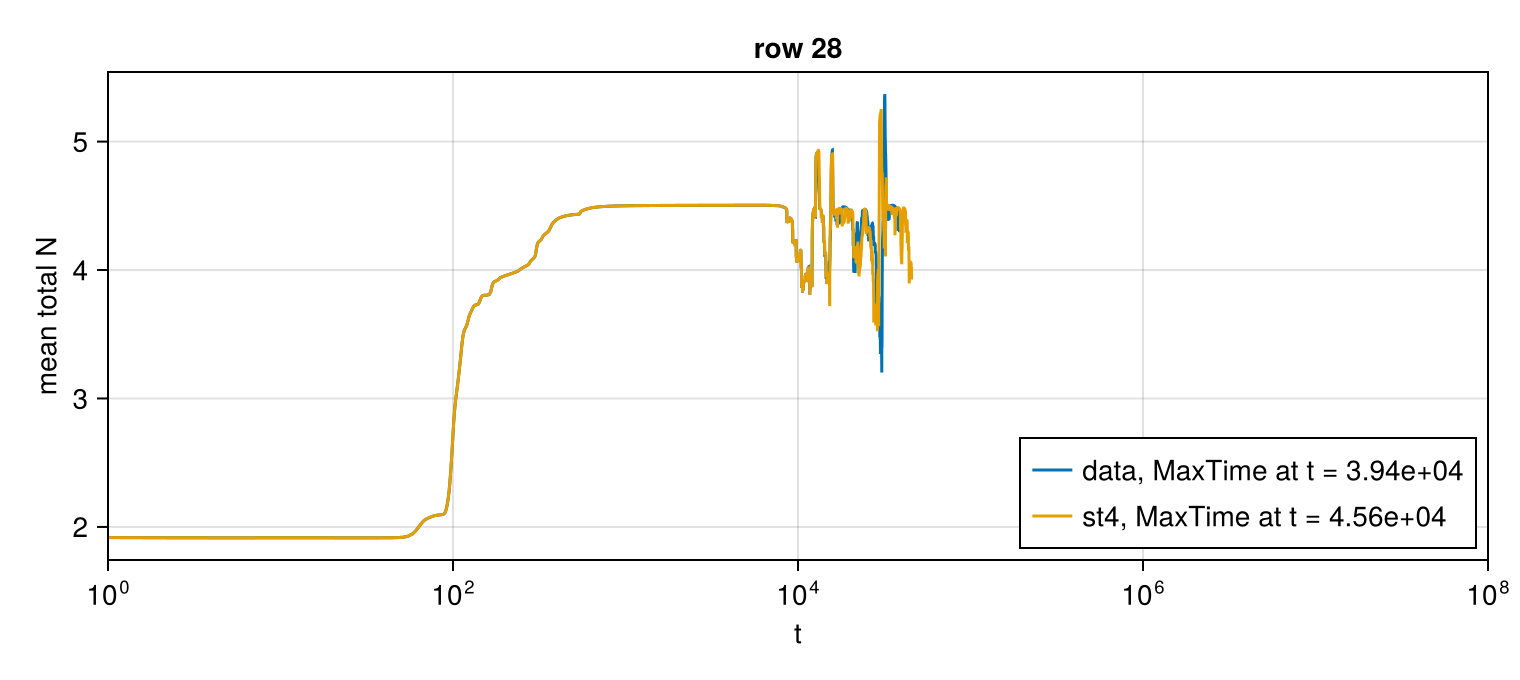

In [21]:
prow = 28                # any pde_df_row
trange = (1e0, T)        # the solver saves a few states at t ~ 1e-17

fig = Figure(; size=(760, 340))
ax = Axis(fig[1, 1]; xscale=log10, xlabel="t", ylabel="mean total N",
    title=@sprintf("row %d", prow))

for g in groupby(df[df.pde_df_row.==prow, :], :run)
    r = only(eachrow(g))
    keep = findall(t -> trange[1] <= t <= trange[2], r.saved_ts)
    lines!(ax, r.saved_ts[keep], r.biomass_t[keep];
        label=@sprintf("%s, %s at t = %.3g", r.run, string(r.retcode), r.final_T))
end
xlims!(ax, trange)
axislegend(ax; position=:rb)

fig